<a href="https://colab.research.google.com/github/sydney142/databases_analytics_assignment/blob/main/Assignment_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# IMPORTING LIBRARIES #
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# UPLOADING FILES #
uploaded_file = files.upload()

# READ FILES #
deliveries_df = pd.read_csv("deliveries.csv")
customers_df = pd.read_csv("customers.csv")
orders_df = pd.read_csv("orders.csv")
incidents_df = pd.read_csv("incidents.csv")
drivers_df = pd.read_csv("drivers.csv")
hubs_df = pd.read_csv("hubs.csv")
complaints_df = pd.read_csv("complaints.csv")
app_events_df = pd.read_csv("app_events.csv")
#

Saving app_events.csv to app_events (1).csv
Saving complaints.csv to complaints (1).csv
Saving customers.csv to customers (1).csv
Saving data_dictionary.csv to data_dictionary (1).csv
Saving deliveries.csv to deliveries (1).csv
Saving drivers.csv to drivers (1).csv
Saving hubs.csv to hubs (1).csv
Saving incidents.csv to incidents (1).csv
Saving orders.csv to orders (1).csv
Saving README.txt to README (1).txt
Saving vehicles.csv to vehicles (1).csv


Check for missing values

In [ ]:
# check number of missing values
complaints_df.isna().sum()

,0
complaint_id,0
customer_id,0
order_id,0
complaint_type,0
channel,0
severity,0
created_at,0
status,0
resolution_days,0
compensation_amount,16


Missing compensation amount values is unaccounted for loss: this is a business problem

In [ ]:
# remove missing values
complaints_df = complaints_df.dropna()

# **Compensation amount analysis**

Histogram for compensation amount: frequency concentrated at lower values

<Axes: >

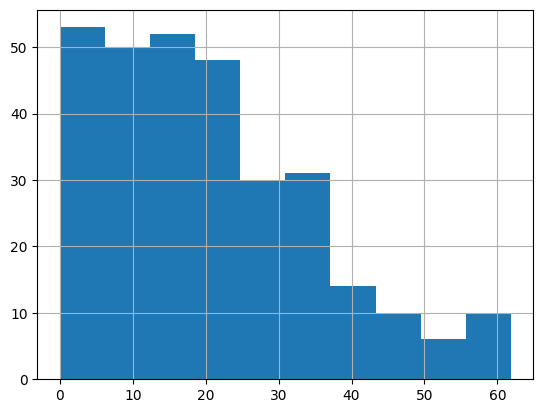

In [ ]:
complaints_df["compensation_amount"].hist()

Correlation of resolution days and compensation amount: weak-medium correlation

In [ ]:
complaints_df.corr(numeric_only=True)["compensation_amount"].sort_values()

,compensation_amount
resolution_days,0.375598
compensation_amount,1.000000


Delivery status and customer rating chart

<Axes: xlabel='delivery_status'>

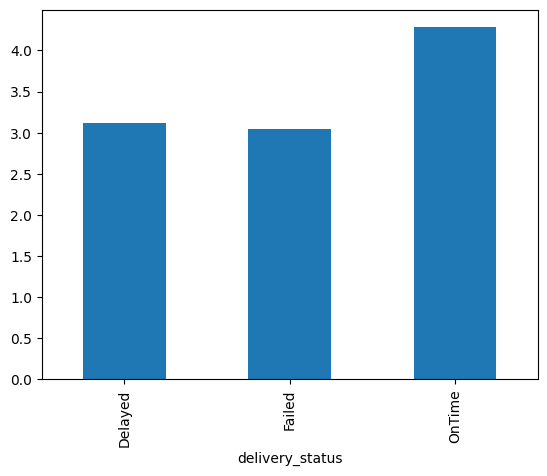

In [ ]:
# Delivery Status and Customer Rating Post Delivery #
deliveries_df.groupby("delivery_status")["customer_rating_post_delivery"].mean().plot(kind="bar")

Customers are highly satisfied when deliveries are on time. On average there is not a large difference in satisfaction when deliveries are delayed vs failed.

<Axes: xlabel='severity'>

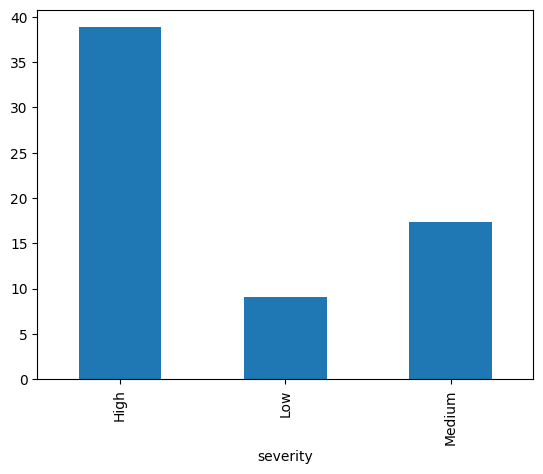

In [23]:
complaints_df.groupby("severity")["compensation_amount"].mean().plot(kind='bar')

<Axes: xlabel='severity'>

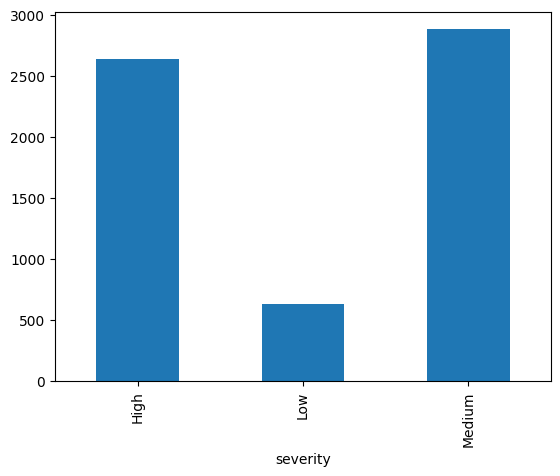

In [24]:
complaints_df.groupby("severity")["compensation_amount"].sum().plot(kind='bar')

CUSTOMER LOYALTY SCORE

In [ ]:
max_loyalty_score = customers_df["loyalty_score"].max()
print(max_loyalty_score)

99.0


In [ ]:
mean_loyalty_score = customers_df["loyalty_score"].mean()
print(mean_loyalty_score)

59.69063492063492


<Axes: xlabel='preferred_channel'>

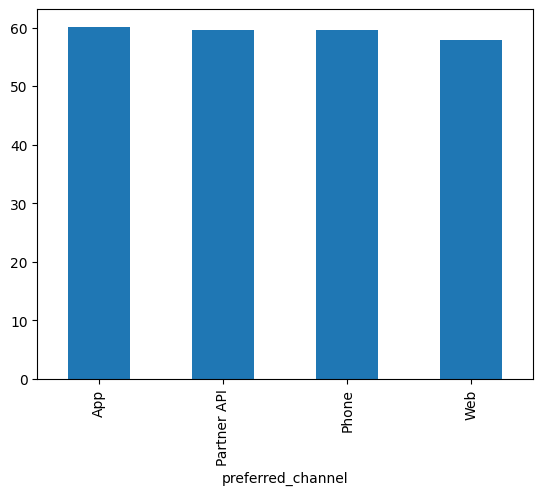

In [ ]:
customers_df.groupby("preferred_channel")["loyalty_score"].mean().plot(kind="bar")

Loyalty score is on average evenly spread across channels

# **Deliveries**

In [2]:
mean_fuel_or_charge_cost = deliveries_df["fuel_or_charge_cost"].mean()
print(mean_fuel_or_charge_cost)

12.841294736842105


In [19]:
print(deliveries_df)

    delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0       DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1       DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2       DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3       DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4       DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   
..          ...      ...       ...        ...    ...                  ...   
945     DL00946   O00982      D069       V058    H04  2025-10-28 08:18:00   
946     DL00947   O01082      D129       V019    H04  2024-10-25 15:52:00   
947     DL00948   O00863      D155       V111    H07  2025-09-17 19:05:00   
948     DL00949   O01106      D060       V005    H02  2024-02-28 01:58:00   
949     DL00950   O00744      D024       V014    H02  2025-04-23 05:31:00   

          delivery_completed_at delivery_status  route_distance_km  \
0    

In [21]:
# creating new dataframe with only failed deliveries
failed_deliveries_df = deliveries_df[deliveries_df['delivery_status']=='Failed']
print(failed_deliveries_df)

    delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0       DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
9       DL00010   O00836      D058       V057    H08  2025-09-22 19:09:00   
11      DL00012   O01207      D051       V017    H05  2024-12-26 19:41:00   
21      DL00022   O01027      D088       V011    H07  2025-08-24 00:21:00   
25      DL00026   O00906      D092       V055    H04  2025-02-04 11:16:00   
..          ...      ...       ...        ...    ...                  ...   
927     DL00928   O00100      D023       V101    H05  2025-10-30 22:51:00   
930     DL00931   O01171      D006       V062    H08  2024-12-18 03:47:00   
934     DL00935   O00211      D107       V012    H08  2024-02-14 07:33:00   
937     DL00938   O01246      D132       V109    H03  2024-04-04 03:20:00   
941     DL00942   O01112      D013       V027    H04  2024-09-24 04:28:00   

          delivery_completed_at delivery_status  route_distance_km  \
0    

In [28]:
# reindexing with forward fill
reindexed_failed_deliveries_df = failed_deliveries_df.ffill()
print(reindexed_failed_deliveries_df)

    delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0       DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
9       DL00010   O00836      D058       V057    H08  2025-09-22 19:09:00   
11      DL00012   O01207      D051       V017    H05  2024-12-26 19:41:00   
21      DL00022   O01027      D088       V011    H07  2025-08-24 00:21:00   
25      DL00026   O00906      D092       V055    H04  2025-02-04 11:16:00   
..          ...      ...       ...        ...    ...                  ...   
927     DL00928   O00100      D023       V101    H05  2025-10-30 22:51:00   
930     DL00931   O01171      D006       V062    H08  2024-12-18 03:47:00   
934     DL00935   O00211      D107       V012    H08  2024-02-14 07:33:00   
937     DL00938   O01246      D132       V109    H03  2024-04-04 03:20:00   
941     DL00942   O01112      D013       V027    H04  2024-09-24 04:28:00   

          delivery_completed_at delivery_status  route_distance_km  \
0    

In [26]:
# creating new dataframe with unsuccessful deliveries
unsuccessful_deliveries_df = deliveries_df[deliveries_df['delivery_status']!='OnTime']
print(unsuccessful_deliveries_df)

    delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0       DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
3       DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
5       DL00006   O00029      D037       V098    H03  2024-09-11 12:40:00   
6       DL00007   O00097      D151       V037    H07  2024-01-09 13:41:00   
9       DL00010   O00836      D058       V057    H08  2025-09-22 19:09:00   
..          ...      ...       ...        ...    ...                  ...   
930     DL00931   O01171      D006       V062    H08  2024-12-18 03:47:00   
934     DL00935   O00211      D107       V012    H08  2024-02-14 07:33:00   
937     DL00938   O01246      D132       V109    H03  2024-04-04 03:20:00   
939     DL00940   O00565      D133       V066    H04  2025-07-01 17:56:00   
941     DL00942   O01112      D013       V027    H04  2024-09-24 04:28:00   

          delivery_completed_at delivery_status  route_distance_km  \
0    

In [27]:
# total fuel cost of unsuccessful deliveries
total_fuel_or_charge_cost_1 = unsuccessful_deliveries_df['fuel_or_charge_cost'].sum()
print(total_fuel_or_charge_cost_1)

4389.549999999999


In [22]:
# sum total fuel cost of failed deliveries
total_fuel_or_charge_cost = failed_deliveries_df['fuel_or_charge_cost'].sum()
print(total_fuel_or_charge_cost)

1735.5300000000002


The total cost of fuel for failed deliveries is £1735.53. This is a business problem as it is a loss.

In [25]:
# mean fuel cost of failed deliveries
mean_fuel_or_charge_cost = failed_deliveries_df['fuel_or_charge_cost'].mean()
print(mean_fuel_or_charge_cost)

13.147954545454548


In [3]:
mean_customer_rating_post_delivery = deliveries_df["customer_rating_post_delivery"].mean()
print(mean_customer_rating_post_delivery)

3.864679487179487


Indexing